# 🧑‍💼 **Workforce Performance & Efficiency Dashboard**
## HR Analytics | Data Cleaning & Exploratory Data Analysis

**Dataset:** HRDataset_v14 (Kaggle — open source)  
**Tools:** Python, pandas, matplotlib, seaborn  
**Author:** Nur Alisa Zarina Nazmi

---

### 📋 Notebook Structure
1. Data Loading
2. Missing Value Analysis
3. Data Cleaning & Consistency Checks
4. Exploratory Data Analysis (EDA)
5. Termination Reason Categorisation
6. Export Cleaned Dataset

In [ ]:
    from google.colab import files
    uploaded = files.upload()

Saving HRDataset_v14.csv to HRDataset_v14.csv


# ⚙️ Setup
Clean the "HRDataset_v14.csv" dataset by handling missing values, inconsistent data, and errors, and provide a step-by-step method used for cleaning.

## 1. 📂 Data Loading

Load the uploaded `HRDataset_v14.csv` file into a pandas DataFrame and inspect its structure.

In [ ]:
import pandas as pd

df = pd.read_csv('HRDataset_v14.csv')
display(df.head())
display(df.info())

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee_Name               311 non-null    object 
 1   EmpID                       311 non-null    int64  
 2   MarriedID                   311 non-null    int64  
 3   MaritalStatusID             311 non-null    int64  
 4   GenderID                    311 non-null    int64  
 5   EmpStatusID                 311 non-null    int64  
 6   DeptID                      311 non-null    int64  
 7   PerfScoreID                 311 non-null    int64  
 8   FromDiversityJobFairID      311 non-null    int64  
 9   Salary                      311 non-null    int64  
 10  Termd                       311 non-null    int64  
 11  PositionID                  311 non-null    int64  
 12  Position                    311 non-null    object 
 13  State                       311 non

None

## 2. 🔎 Missing Value Identification

Check for missing values across all columns and visualise their distribution using a heatmap.

Missing values per column:


,Missing Count,Missing Percentage
DateofTermination,207,66.559486
ManagerID,8,2.572347


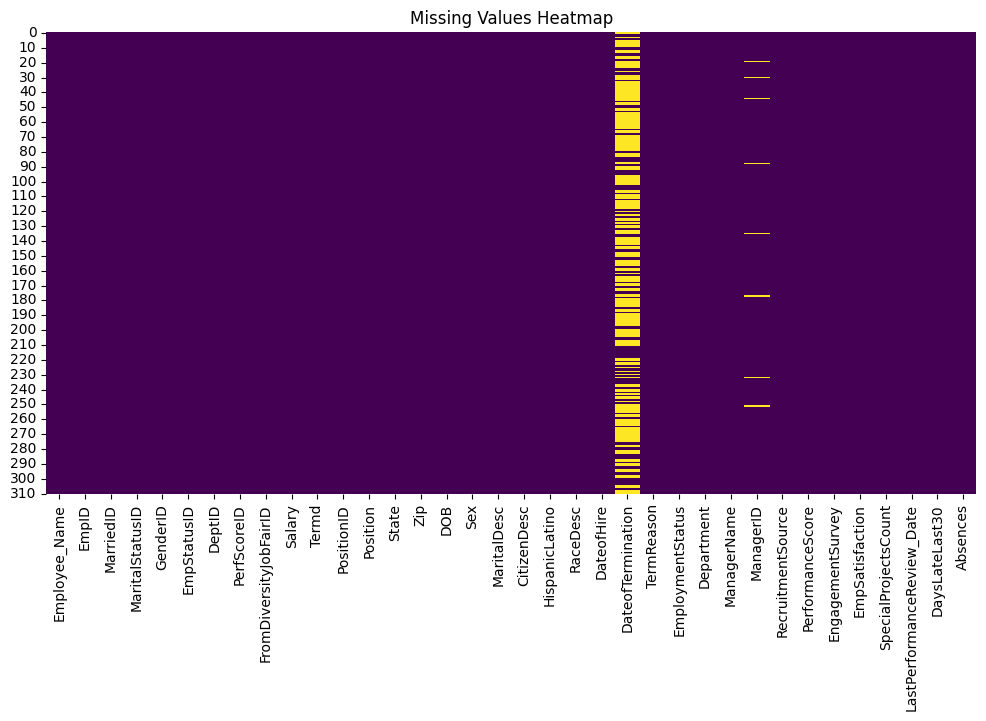

In [ ]:
missing_values = df.isnull().sum()
missing_values_percentage = (missing_values / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_values_percentage
})

print("Missing values per column:")
display(missing_info[missing_info['Missing Count'] > 0])

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

## 3. 🧹 Missing Value Handling

Two columns contain missing values:

- **`DateofTermination`** — Nulls are intentionally retained. A blank termination date indicates the employee is still active. Filling these would misrepresent employment status.
- **`ManagerID`** — Nulls are filled with `-1` as a placeholder to distinguish employees without an assigned manager from those with a valid manager ID.

In [ ]:
# Analyze missing values for the target columns
print("Missing values for DateofTermination:")
display(missing_info.loc[['DateofTermination']])

print("\nMissing values for ManagerID:")
display(missing_info.loc[['ManagerID']])

# Strategy: For 'DateofTermination', missing values likely indicate active employees.
# We will not fill these as they convey meaningful information (employee is active).
# If a specific placeholder was needed for a particular analysis, it would be applied
# later, but for general cleaning, leaving as NaN is appropriate.

# Strategy: For 'ManagerID', fill missing values with a placeholder, e.g., -1,
# assuming ManagerID values are non-negative. This distinguishes employees
# without a listed manager from those with an actual manager ID.
df['ManagerID'] = df['ManagerID'].fillna(-1)

# Verify that missing values in 'ManagerID' have been handled
print("\nMissing values after handling ManagerID:")
display(df[['DateofTermination', 'ManagerID']].isnull().sum())

Missing values for DateofTermination:


,Missing Count,Missing Percentage
DateofTermination,207,66.559486



Missing values for ManagerID:


,Missing Count,Missing Percentage
ManagerID,8,2.572347



Missing values after handling ManagerID:


,0
DateofTermination,207
ManagerID,0


## 4. 🔍 Inconsistency & Error Detection

Investigate data types, descriptive statistics, and relationships between paired columns to surface any inconsistencies or errors.

Checks performed:
- Date columns converted to datetime and validated for logical correctness (no future DOBs, no termination before hire)
- `MaritalStatusID` vs `MaritalDesc` consistency
- `GenderID` vs `Sex` consistency
- `PerfScoreID` vs `PerformanceScore` consistency

In [ ]:
# 1. Examine data types
print("Data types of each column:")
display(df.info())

# 2. Calculate descriptive statistics for numerical columns
print("\nDescriptive statistics for numerical columns:")
display(df.describe())

# 3. Check unique values for categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
print("\nUnique values and counts for categorical columns:")
for col in categorical_cols:
    print(f"\nColumn: {col}")
    display(df[col].value_counts())

Data types of each column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee_Name               311 non-null    object 
 1   EmpID                       311 non-null    int64  
 2   MarriedID                   311 non-null    int64  
 3   MaritalStatusID             311 non-null    int64  
 4   GenderID                    311 non-null    int64  
 5   EmpStatusID                 311 non-null    int64  
 6   DeptID                      311 non-null    int64  
 7   PerfScoreID                 311 non-null    int64  
 8   FromDiversityJobFairID      311 non-null    int64  
 9   Salary                      311 non-null    int64  
 10  Termd                       311 non-null    int64  
 11  PositionID                  311 non-null    int64  
 12  Position                    311 non-null    object 
 13  State   

None


Descriptive statistics for numerical columns:


,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,Termd,PositionID,Zip,ManagerID,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences
count,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000
mean,10156.000000,0.398714,0.810289,0.434084,2.392283,4.610932,2.977492,0.093248,69020.684887,0.334405,16.845659,6555.482315,14.170418,4.110000,3.890675,1.218650,0.414791,10.237942
std,89.922189,0.490423,0.943239,0.496435,1.794383,1.083487,0.587072,0.291248,25156.636930,0.472542,6.223419,16908.396884,8.346907,0.789938,0.909241,2.349421,1.294519,5.852596
min,10001.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,45046.000000,0.000000,1.000000,1013.000000,-1.000000,1.120000,1.000000,0.000000,0.000000,1.000000
25%,10078.500000,0.000000,0.000000,0.000000,1.000000,5.000000,3.000000,0.000000,55501.500000,0.000000,18.000000,1901.500000,9.500000,3.690000,3.000000,0.000000,0.000000,5.000000
50%,10156.000000,0.000000,1.000000,0.000000,1.000000,5.000000,3.000000,0.000000,62810.000000,0.000000,19.000000,2132.000000,14.000000,4.280000,4.000000,0.000000,0.000000,10.000000
75%,10233.500000,1.000000,1.000000,1.000000,5.000000,5.000000,3.000000,0.000000,72036.000000,1.000000,20.000000,2355.000000,19.000000,4.700000,5.000000,0.000000,0.000000,15.000000
max,10311.000000,1.000000,4.000000,1.000000,5.000000,6.000000,4.000000,1.000000,250000.000000,1.000000,30.000000,98052.000000,39.000000,5.000000,5.000000,8.000000,6.000000,20.000000



Unique values and counts for categorical columns:

Column: Employee_Name


...

,count
RecruitmentSource,
Indeed,87
LinkedIn,76
Google Search,49
Employee Referral,31
Diversity Job Fair,29
CareerBuilder,23
Website,13
Other,2
On-line Web application,1



Column: PerformanceScore


,count
PerformanceScore,
Fully Meets,243
Exceeds,37
Needs Improvement,18
PIP,13



Column: LastPerformanceReview_Date


,count
LastPerformanceReview_Date,
1/14/2019,18
2/18/2019,12
1/21/2019,10
1/28/2019,9
2/25/2019,9
...,...
5/15/2014,1
2/6/2011,1
6/2/2014,1


In [ ]:
# 4. Explore date columns
date_cols = ['DOB', 'DateofHire', 'DateofTermination', 'LastPerformanceReview_Date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print("\nChecking for illogical dates:")
illogical_dob = df[df['DOB'] > pd.to_datetime('now', utc=True)]
print(f"Employees with DOB in the future: {len(illogical_dob)}")
if not illogical_dob.empty:
    display(illogical_dob[['Employee_Name', 'DOB']])

illogical_hire_date = df[df['DateofHire'] > pd.to_datetime('now', utc=True)]
print(f"Employees with DateofHire in the future: {len(illogical_hire_date)}")
if not illogical_hire_date.empty:
    display(illogical_hire_date[['Employee_Name', 'DateofHire']])

illogical_termination_date = df[df['DateofTermination'].notnull() & (df['DateofTermination'] < df['DateofHire'])]
print(f"Employees with DateofTermination before DateofHire: {len(illogical_termination_date)}")
if not illogical_termination_date.empty:
    display(illogical_termination_date[['Employee_Name', 'DateofHire', 'DateofTermination']])

# 5. Investigate relationships between related columns
print("\nChecking consistency between related ID and description columns:")

# Marital Status
marital_status_mismatch = df[df['MaritalStatusID'].astype(str) != df['MaritalDesc'].map({'Single': '0', 'Married': '1', 'Divorced': '2', 'Separated': '3', 'Widowed': '4'})]
print(f"Employees with MaritalStatusID and MaritalDesc mismatch: {len(marital_status_mismatch)}")
if not marital_status_mismatch.empty:
    display(marital_status_mismatch[['Employee_Name', 'MaritalStatusID', 'MaritalDesc']])

# Gender
gender_mismatch = df[df['GenderID'].astype(str) != df['Sex'].map({'Female': '0', 'Male': '1', 'F': '0', 'M': '1'})]
print(f"Employees with GenderID and Sex mismatch: {len(gender_mismatch)}")
if not gender_mismatch.empty:
    display(gender_mismatch[['Employee_Name', 'GenderID', 'Sex']])

# Performance Score
performance_score_mapping = {
    'Fully Meets': '3',
    'Exceeds': '4',
    'Needs Improvement': '2',
    'PIP': '1',
    'Exceptional': '5', # Assuming 'Exceptional' might map to 5 if it exists
    'Outstanding': '4' # Assuming 'Outstanding' might map to 4 if it exists
}
performance_score_mismatch = df[df['PerfScoreID'].astype(str) != df['PerformanceScore'].map(performance_score_mapping)]
print(f"Employees with PerfScoreID and PerformanceScore mismatch: {len(performance_score_mismatch)}")
if not performance_score_mismatch.empty:
    display(performance_score_mismatch[['Employee_Name', 'PerfScoreID', 'PerformanceScore']])


Checking for illogical dates:


/tmp/ipython-input-9-1674086618.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors='coerce')


TypeError: Invalid comparison between dtype=datetime64[ns] and Timestamp

**Note**:
The previous attempt to compare datetime objects failed due to a timezone mismatch. Convert the comparison timestamp to be timezone-naive to match the DataFrame's datetime objects. Then, continue with the remaining checks for illogical dates and the investigation of relationships between related ID and description columns.



In [ ]:
# Continue exploring date columns with timezone-naive comparison
now_naive = pd.to_datetime('now').tz_localize(None)

print("\nChecking for illogical dates:")
illogical_dob = df[df['DOB'] > now_naive]
print(f"Employees with DOB in the future: {len(illogical_dob)}")
if not illogical_dob.empty:
    display(illogical_dob[['Employee_Name', 'DOB']])

illogical_hire_date = df[df['DateofHire'] > now_naive]
print(f"Employees with DateofHire in the future: {len(illogical_hire_date)}")
if not illogical_hire_date.empty:
    display(illogical_hire_date[['Employee_Name', 'DateofHire']])

illogical_termination_date = df[df['DateofTermination'].notnull() & (df['DateofTermination'] < df['DateofHire'])]
print(f"Employees with DateofTermination before DateofHire: {len(illogical_termination_date)}")
if not illogical_termination_date.empty:
    display(illogical_termination_date[['Employee_Name', 'DateofHire', 'DateofTermination']])

# 5. Investigate relationships between related columns
print("\nChecking consistency between related ID and description columns:")

# Marital Status
marital_status_mapping = {'Single': 0, 'Married': 1, 'Divorced': 2, 'Separated': 3, 'Widowed': 4}
marital_status_mismatch = df[df['MaritalStatusID'] != df['MaritalDesc'].map(marital_status_mapping)]
print(f"Employees with MaritalStatusID and MaritalDesc mismatch: {len(marital_status_mismatch)}")
if not marital_status_mismatch.empty:
    display(marital_status_mismatch[['Employee_Name', 'MaritalStatusID', 'MaritalDesc']])

# Gender
gender_mapping = {'Female': 0, 'Male': 1, 'F': 0, 'M': 1}
gender_mismatch = df[df['GenderID'] != df['Sex'].map(gender_mapping)]
print(f"Employees with GenderID and Sex mismatch: {len(gender_mismatch)}")
if not gender_mismatch.empty:
    display(gender_mismatch[['Employee_Name', 'GenderID', 'Sex']])

# Performance Score
performance_score_mapping = {
    'Fully Meets': 3,
    'Exceeds': 4,
    'Needs Improvement': 2,
    'PIP': 1
}
performance_score_mismatch = df[df['PerfScoreID'] != df['PerformanceScore'].map(performance_score_mapping)]
print(f"Employees with PerfScoreID and PerformanceScore mismatch: {len(performance_score_mismatch)}")
if not performance_score_mismatch.empty:
    display(performance_score_mismatch[['Employee_Name', 'PerfScoreID', 'PerformanceScore']])


Checking for illogical dates:
Employees with DOB in the future: 91


,Employee_Name,DOB
8,"Bachiochi, Linda",2070-02-11
10,"Baczenski, Rachael",2074-01-12
11,"Barbara, Thomas",2074-02-21
16,"Beak, Kimberly",2066-04-17
17,"Beatrice, Courtney",2070-10-27
...,...,...
290,"Vega, Vincent",2068-10-10
296,"Wallace, Courtney E",2055-11-14
301,"Wilber, Barry",2065-09-09
303,"Williams, Jacquelyn",2069-10-02


Employees with DateofHire in the future: 0
Employees with DateofTermination before DateofHire: 0

Checking consistency between related ID and description columns:
Employees with MaritalStatusID and MaritalDesc mismatch: 0
Employees with GenderID and Sex mismatch: 135


,Employee_Name,GenderID,Sex
0,"Adinolfi, Wilson K",1,M
1,"Ait Sidi, Karthikeyan",1,M
7,"Athwal, Sam",1,M
9,"Bacong, Alejandro",1,M
11,"Barbara, Thomas",1,M
...,...,...,...
298,"Wang, Charlie",1,M
300,"Whittier, Scott",1,M
301,"Wilber, Barry",1,M
304,"Winthrop, Jordan",1,M


Employees with PerfScoreID and PerformanceScore mismatch: 2


,Employee_Name,PerfScoreID,PerformanceScore
64,"Dee, Randy",1,Fully Meets
95,"Forrest, Alex",3,PIP


## 5. ✏️ Data Cleaning

Apply corrections based on findings from the previous step:
- Strip whitespace from `Sex` column
- Capitalise `HispanicLatino` values for consistency
- Correct `PerformanceScore` mismatches to align with `PerfScoreID`
- Confirm date columns are in proper datetime format

### ✅ Verification

Re-examine cleaned columns to confirm all inconsistencies have been resolved before proceeding to analysis.

In [ ]:
# Re-examine data types of date columns
print("Data types of date columns after cleaning:")
display(df[['DOB', 'DateofHire', 'DateofTermination', 'LastPerformanceReview_Date']].info())

# Re-check unique values for cleaned categorical columns
print("\nUnique values and counts for cleaned categorical columns:")

print("\nColumn: Sex")
display(df['Sex'].value_counts())

print("\nColumn: HispanicLatino")
display(df['HispanicLatino'].value_counts())

print("\nColumn: PerformanceScore")
display(df['PerformanceScore'].value_counts())

# Re-check for gender mismatches to confirm correction
gender_mapping = {'Female': 0, 'Male': 1}
gender_mismatch_after_cleaning = df[df['GenderID'] != df['Sex'].map(gender_mapping)]
print(f"\nEmployees with GenderID and Sex mismatch after cleaning: {len(gender_mismatch_after_cleaning)}")
if not gender_mismatch_after_cleaning.empty:
    display(gender_mismatch_after_cleaning[['Employee_Name', 'GenderID', 'Sex']])

# Re-check for performance score mismatches to confirm correction
performance_score_mapping = {
    'Fully Meets': 3,
    'Exceeds': 4,
    'Needs Improvement': 2,
    'PIP': 1
}
performance_score_mismatch_after_cleaning = df[df['PerfScoreID'] != df['PerformanceScore'].map(performance_score_mapping)]
print(f"Employees with PerfScoreID and PerformanceScore mismatch after cleaning: {len(performance_score_mismatch_after_cleaning)}")
if not performance_score_mismatch_after_cleaning.empty:
    display(performance_score_mismatch_after_cleaning[['Employee_Name', 'PerfScoreID', 'PerformanceScore']])

Data types of date columns after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 4 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   DOB                         311 non-null    datetime64[ns]
 1   DateofHire                  311 non-null    datetime64[ns]
 2   DateofTermination           104 non-null    datetime64[ns]
 3   LastPerformanceReview_Date  311 non-null    datetime64[ns]
dtypes: datetime64[ns](4)
memory usage: 9.8 KB


None


Unique values and counts for cleaned categorical columns:

Column: Sex


,count
Sex,
F,176
M,135



Column: HispanicLatino


...

,count
PerformanceScore,
Fully Meets,243
Exceeds,37
Needs Improvement,18
PIP,13



Employees with GenderID and Sex mismatch after cleaning: 311


,Employee_Name,GenderID,Sex
0,"Adinolfi, Wilson K",1,M
1,"Ait Sidi, Karthikeyan",1,M
2,"Akinkuolie, Sarah",0,F
3,"Alagbe,Trina",0,F
4,"Anderson, Carol",0,F
...,...,...,...
306,"Woodson, Jason",1,M
307,"Ybarra, Catherine",0,F
308,"Zamora, Jennifer",0,F
309,"Zhou, Julia",0,F


Employees with PerfScoreID and PerformanceScore mismatch after cleaning: 2


,Employee_Name,PerfScoreID,PerformanceScore
64,"Dee, Randy",1,Fully Meets
95,"Forrest, Alex",3,PIP


## 6. 📊 Exploratory Data Analysis (EDA)

### 6.1 Data Overview

Display descriptive statistics and schema information to get a high-level understanding of the cleaned dataset.

In [ ]:
display(df.head())
display(df.info())
display(df.describe())

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,2019-01-17,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2016-02-24,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,2012-05-15,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,2019-01-03,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2016-02-01,0,2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Employee_Name               311 non-null    object        
 1   EmpID                       311 non-null    int64         
 2   MarriedID                   311 non-null    int64         
 3   MaritalStatusID             311 non-null    int64         
 4   GenderID                    311 non-null    int64         
 5   EmpStatusID                 311 non-null    int64         
 6   DeptID                      311 non-null    int64         
 7   PerfScoreID                 311 non-null    int64         
 8   FromDiversityJobFairID      311 non-null    int64         
 9   Salary                      311 non-null    int64         
 10  Termd                       311 non-null    int64         
 11  PositionID                  311 non-null    int64         

None

,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,Termd,...,DOB,DateofHire,DateofTermination,ManagerID,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
count,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,311.000000,...,311,311,104,311.000000,311.000000,311.000000,311.000000,311,311.000000,311.000000
mean,10156.000000,0.398714,0.810289,0.434084,2.392283,4.610932,2.977492,0.093248,69020.684887,0.334405,...,2008-05-11 18:54:24.308681728,2013-02-03 22:50:32.797427712,2015-06-14 11:46:09.230769152,14.170418,4.110000,3.890675,1.218650,2017-09-10 21:17:56.527331072,0.414791,10.237942
min,10001.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,45046.000000,0.000000,...,1975-03-10 00:00:00,2006-01-09 00:00:00,2010-08-30 00:00:00,-1.000000,1.120000,1.000000,0.000000,2010-07-14 00:00:00,0.000000,1.000000
25%,10078.500000,0.000000,0.000000,0.000000,1.000000,5.000000,3.000000,0.000000,55501.500000,0.000000,...,1981-11-09 00:00:00,2011-07-11 00:00:00,2014-01-10 12:00:00,9.500000,3.690000,3.000000,0.000000,2016-03-19 12:00:00,0.000000,5.000000
50%,10156.000000,0.000000,1.000000,0.000000,1.000000,5.000000,3.000000,0.000000,62810.000000,0.000000,...,1986-11-07 00:00:00,2013-02-18 00:00:00,2015-09-22 00:00:00,14.000000,4.280000,4.000000,0.000000,2019-01-16 00:00:00,0.000000,10.000000
75%,10233.500000,1.000000,1.000000,1.000000,5.000000,5.000000,3.000000,0.000000,72036.000000,1.000000,...,2060-07-19 00:00:00,2014-09-23 12:00:00,2016-09-08 06:00:00,19.000000,4.700000,5.000000,0.000000,2019-02-04 00:00:00,0.000000,15.000000
max,10311.000000,1.000000,4.000000,1.000000,5.000000,6.000000,4.000000,1.000000,250000.000000,1.000000,...,2074-12-21 00:00:00,2018-07-09 00:00:00,2018-11-10 00:00:00,39.000000,5.000000,5.000000,8.000000,2019-02-28 00:00:00,6.000000,20.000000
std,89.922189,0.490423,0.943239,0.496435,1.794383,1.083487,0.587072,0.291248,25156.636930,0.472542,...,NaN,NaN,NaN,8.346907,0.789938,0.909241,2.349421,NaN,1.294519,5.852596


### 6.2 Key Variable Distributions

Visualise the distribution of key categorical and numerical variables: `Department`, `Position`, `Salary`, and `PerformanceScore`.

/tmp/ipython-input-14-1387569897.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Department', order=df['Department'].value_counts().index, palette='viridis')


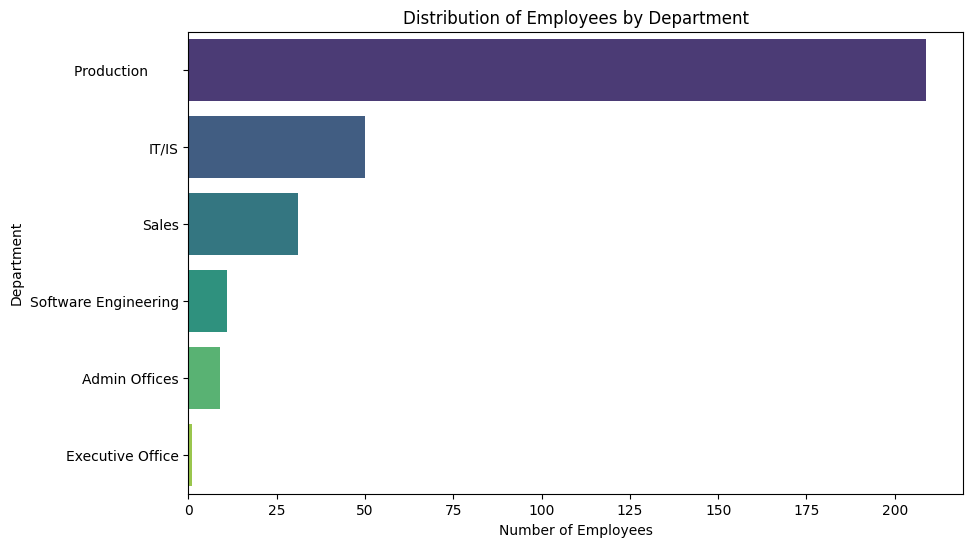

/tmp/ipython-input-14-1387569897.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Position', order=df['Position'].value_counts().index, palette='viridis')


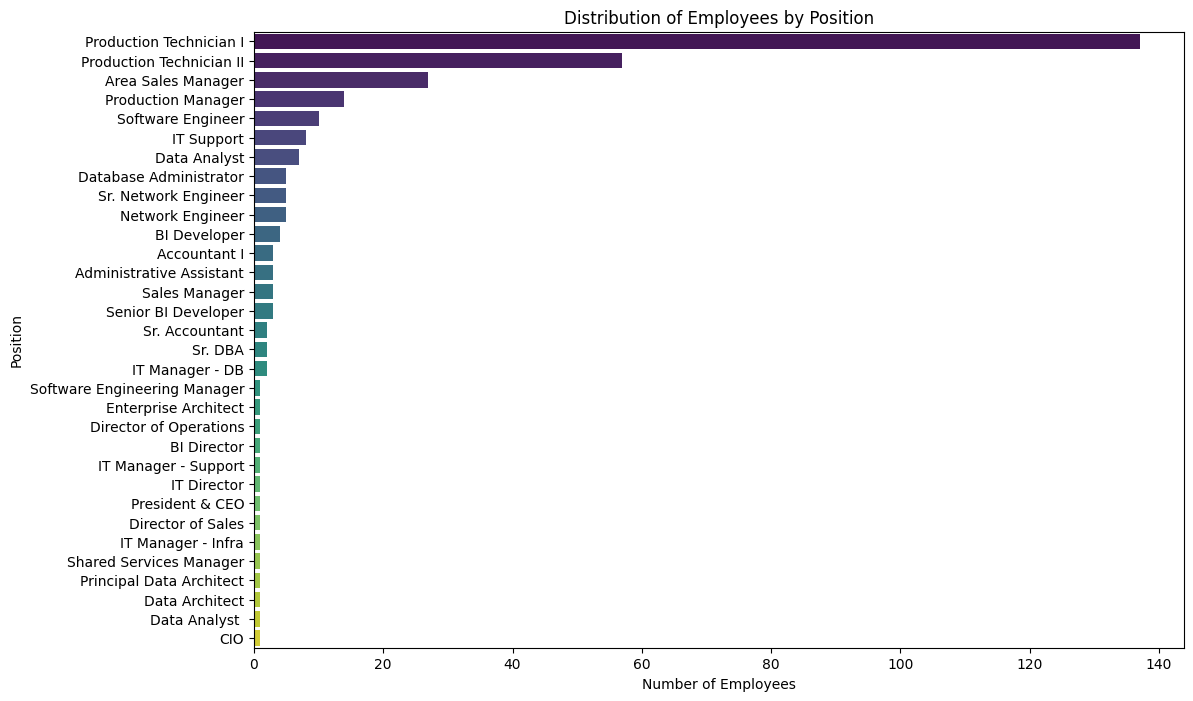

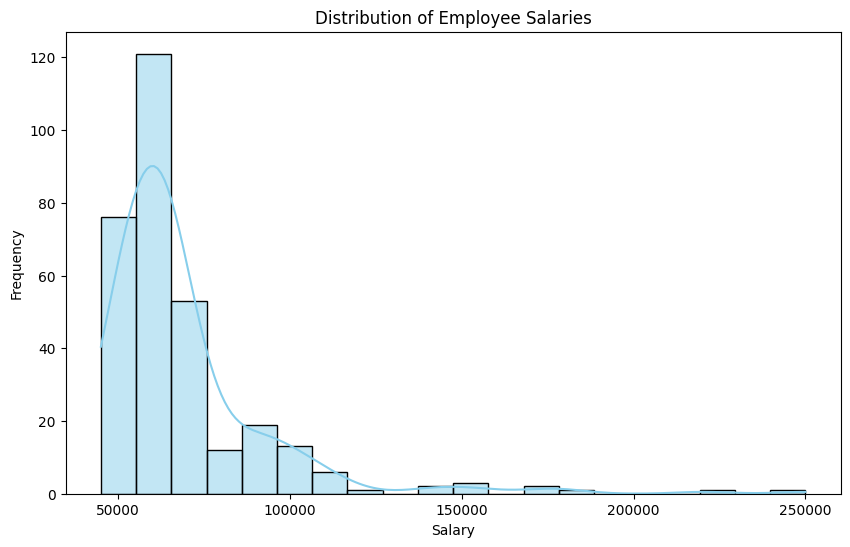

/tmp/ipython-input-14-1387569897.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='PerformanceScore', order=df['PerformanceScore'].value_counts().index, palette='viridis')


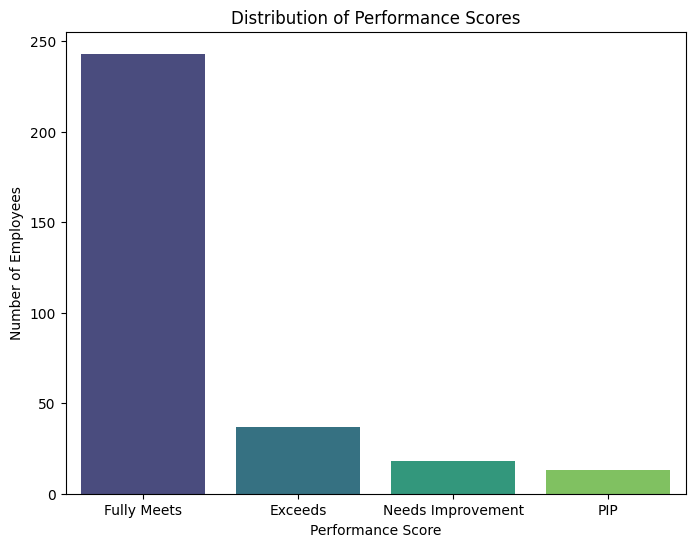

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Bar plot for 'Department'
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='Department', order=df['Department'].value_counts().index, palette='viridis')
plt.title('Distribution of Employees by Department')
plt.xlabel('Number of Employees')
plt.ylabel('Department')
plt.show()

# 2. Bar plot for 'Position'
plt.figure(figsize=(12, 8))
sns.countplot(data=df, y='Position', order=df['Position'].value_counts().index, palette='viridis')
plt.title('Distribution of Employees by Position')
plt.xlabel('Number of Employees')
plt.ylabel('Position')
plt.show()

# 3. Histogram for 'Salary'
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Salary', kde=True, bins=20, color='skyblue')
plt.title('Distribution of Employee Salaries')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

# 4. Bar plot for 'PerformanceScore'
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='PerformanceScore', order=df['PerformanceScore'].value_counts().index, palette='viridis')
plt.title('Distribution of Performance Scores')
plt.xlabel('Performance Score')
plt.ylabel('Number of Employees')
plt.show()

### 6.3 Relationships Between Variables

Explore how salary relates to department and performance, and whether engagement scores correlate with employee satisfaction.

/tmp/ipython-input-15-1660735314.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Salary', y='Department', palette='viridis')


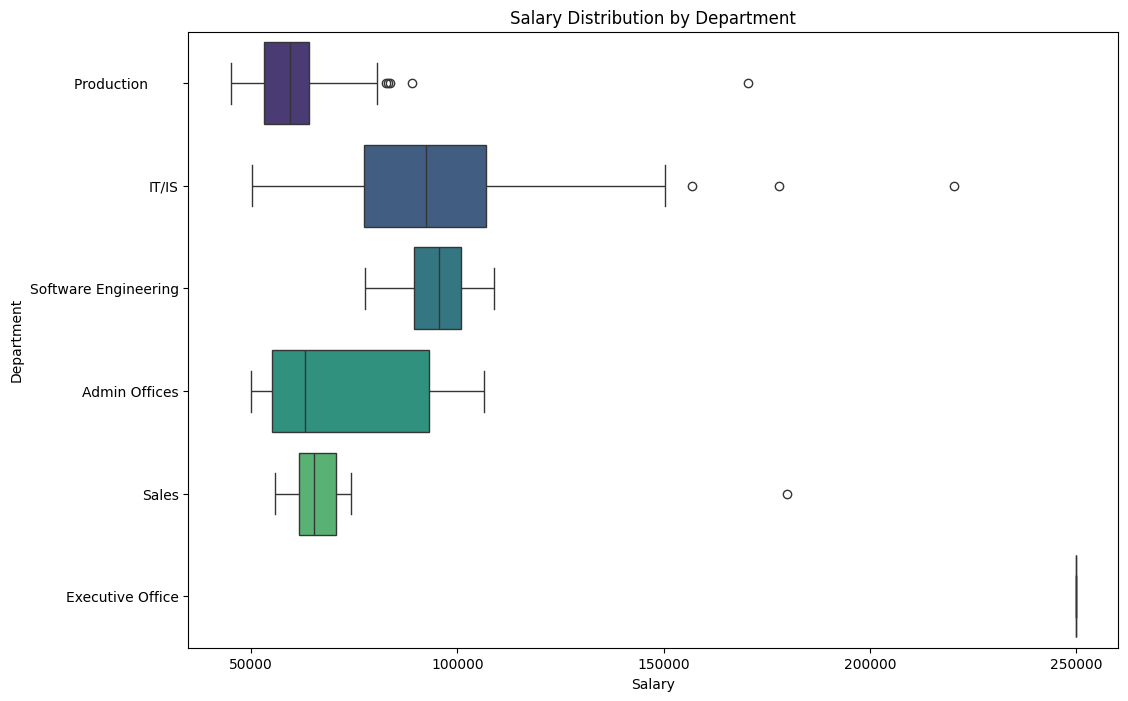

/tmp/ipython-input-15-1660735314.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='PerformanceScore', y='Salary', palette='viridis',


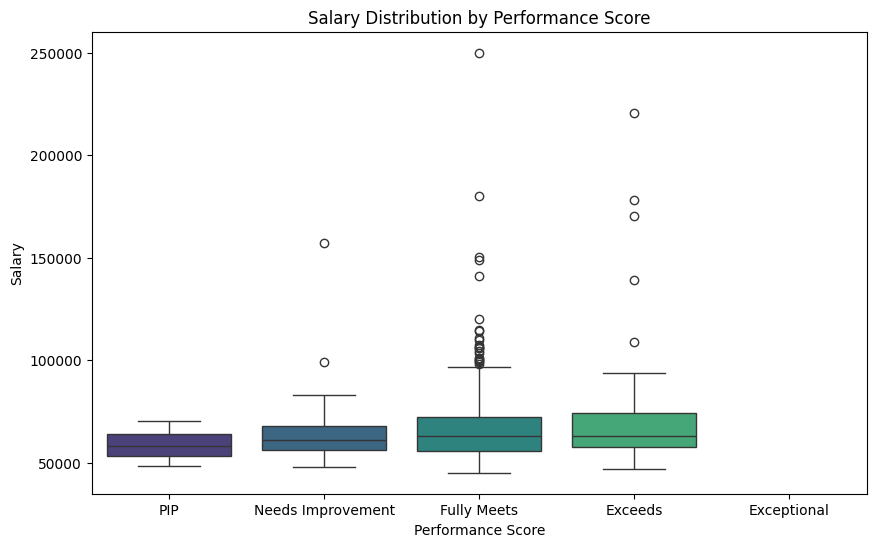

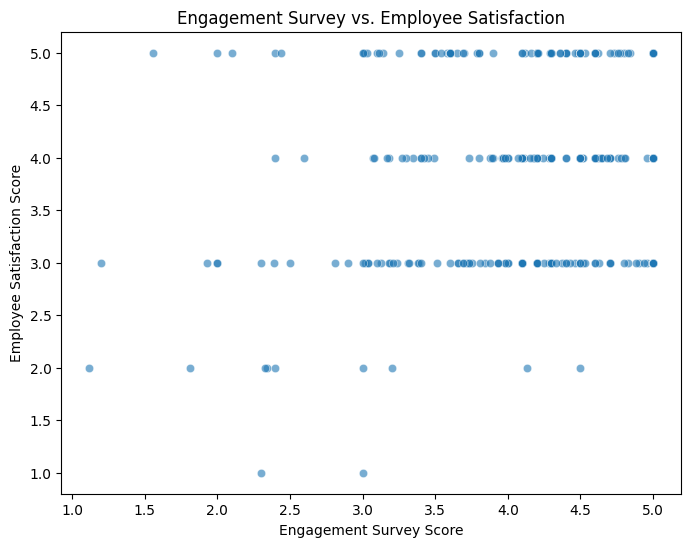

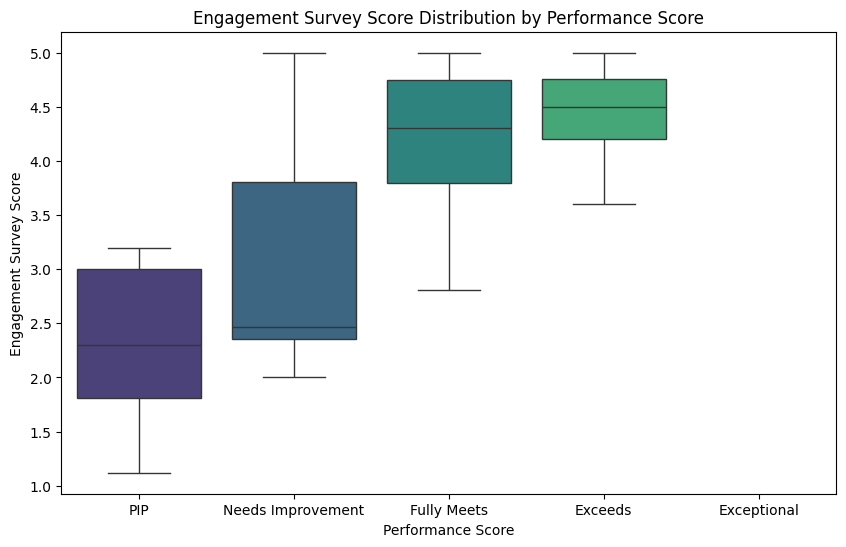

In [ ]:
# 1. Box plot for 'Department' and 'Salary'
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x='Salary', y='Department', palette='viridis')
plt.title('Salary Distribution by Department')
plt.xlabel('Salary')
plt.ylabel('Department')
plt.show()

# 2. Box plot for 'PerformanceScore' and 'Salary'
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='PerformanceScore', y='Salary', palette='viridis',
            order=['PIP', 'Needs Improvement', 'Fully Meets', 'Exceeds', 'Exceptional']) # Ordering by perceived performance level
plt.title('Salary Distribution by Performance Score')
plt.xlabel('Performance Score')
plt.ylabel('Salary')
plt.show()

# 3. Scatter plot for 'EngagementSurvey' and 'EmpSatisfaction'
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='EngagementSurvey', y='EmpSatisfaction', alpha=0.6)
plt.title('Engagement Survey vs. Employee Satisfaction')
plt.xlabel('Engagement Survey Score')
plt.ylabel('Employee Satisfaction Score')
plt.show()

# 4. Box plot for 'PerformanceScore' and 'EngagementSurvey'
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='PerformanceScore', y='EngagementSurvey', palette='viridis',
            order=['PIP', 'Needs Improvement', 'Fully Meets', 'Exceeds', 'Exceptional']) # Ordering by perceived performance level
plt.title('Engagement Survey Score Distribution by Performance Score')
plt.xlabel('Performance Score')
plt.ylabel('Engagement Survey Score')
plt.show()

### 6.4 Employee Demographics

Examine the distribution of `Sex`, `MaritalDesc`, and `RaceDesc` across the workforce.

/tmp/ipython-input-16-133198657.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sex', palette='viridis')


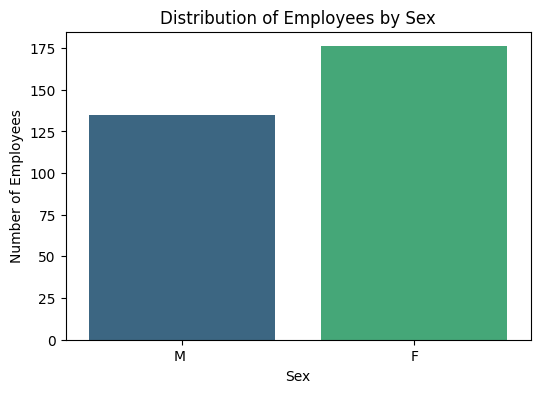

/tmp/ipython-input-16-133198657.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='MaritalDesc', palette='viridis')


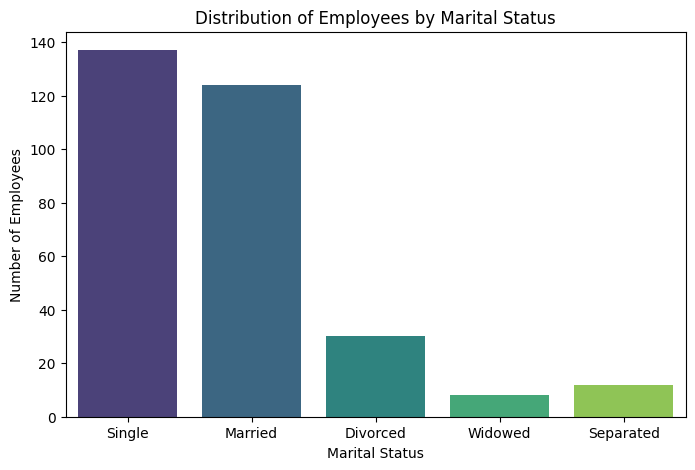

/tmp/ipython-input-16-133198657.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='RaceDesc', order=df['RaceDesc'].value_counts().index, palette='viridis')


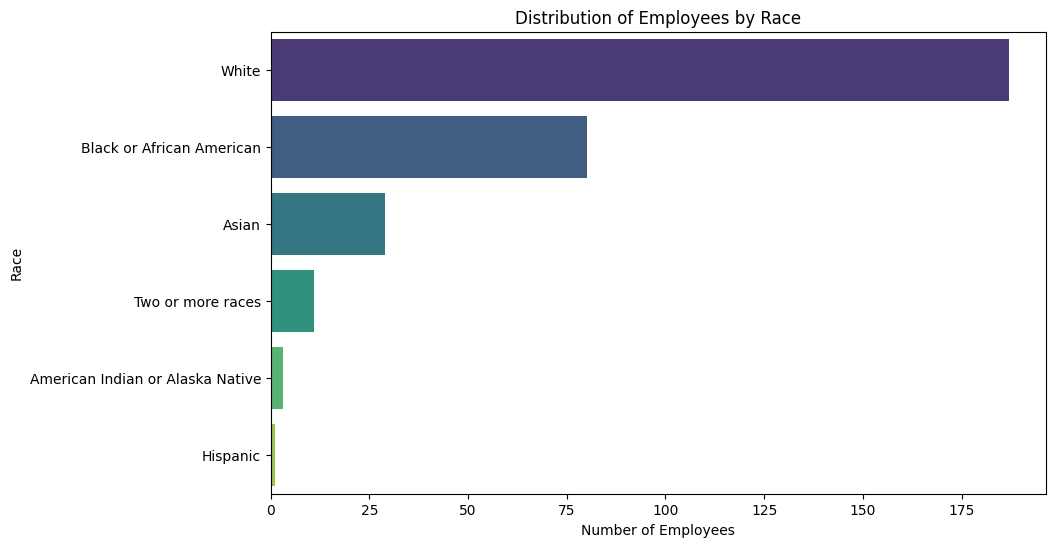

In [ ]:
# 1. Bar plot for 'Sex'
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Sex', palette='viridis')
plt.title('Distribution of Employees by Sex')
plt.xlabel('Sex')
plt.ylabel('Number of Employees')
plt.show()

# 2. Bar plot for 'MaritalDesc'
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='MaritalDesc', palette='viridis')
plt.title('Distribution of Employees by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Number of Employees')
plt.show()

# 3. Bar plot for 'RaceDesc'
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='RaceDesc', order=df['RaceDesc'].value_counts().index, palette='viridis')
plt.title('Distribution of Employees by Race')
plt.xlabel('Number of Employees')
plt.ylabel('Race')
plt.show()

### 6.5 Employment Status & Termination Reasons

Examine `EmploymentStatus` distribution and explore the reasons behind employee departures among non-active employees.

/tmp/ipython-input-17-2577038521.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='EmploymentStatus', order=df['EmploymentStatus'].value_counts().index, palette='viridis')


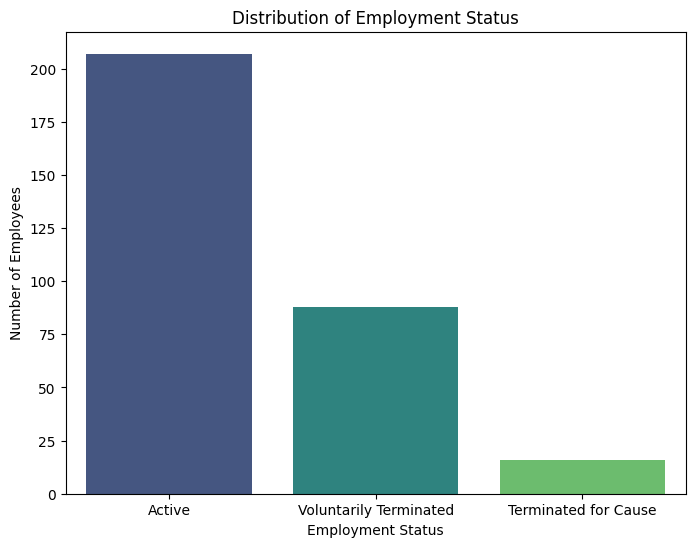

/tmp/ipython-input-17-2577038521.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=terminated_employees, y='TermReason', order=terminated_employees['TermReason'].value_counts().index, palette='viridis')


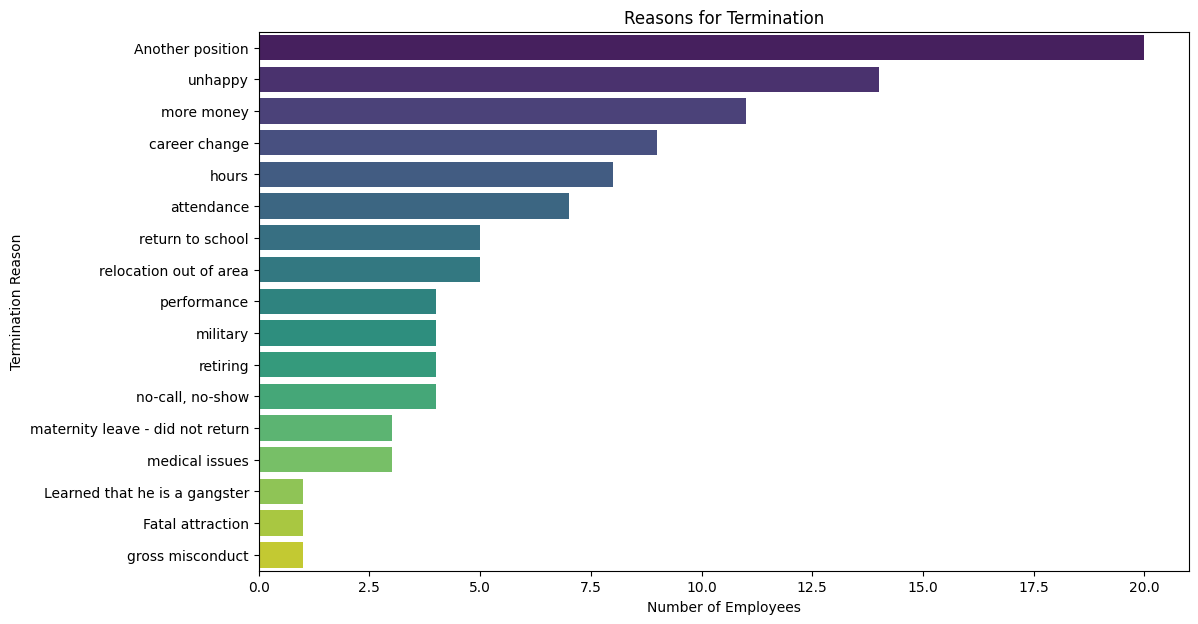

In [ ]:
# 1. Bar plot for 'EmploymentStatus'
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='EmploymentStatus', order=df['EmploymentStatus'].value_counts().index, palette='viridis')
plt.title('Distribution of Employment Status')
plt.xlabel('Employment Status')
plt.ylabel('Number of Employees')
plt.show()

# 2. Bar plot for 'TermReason' for non-active employees
terminated_employees = df[df['EmploymentStatus'] != 'Active']
plt.figure(figsize=(12, 7))
sns.countplot(data=terminated_employees, y='TermReason', order=terminated_employees['TermReason'].value_counts().index, palette='viridis')
plt.title('Reasons for Termination')
plt.xlabel('Number of Employees')
plt.ylabel('Termination Reason')
plt.show()

### 6.6 Recruitment Source Analysis

Investigate which recruitment sources bring in the most employees and how they relate to salary, performance, and retention.

/tmp/ipython-input-18-2945738785.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='RecruitmentSource', order=df['RecruitmentSource'].value_counts().index, palette='viridis')


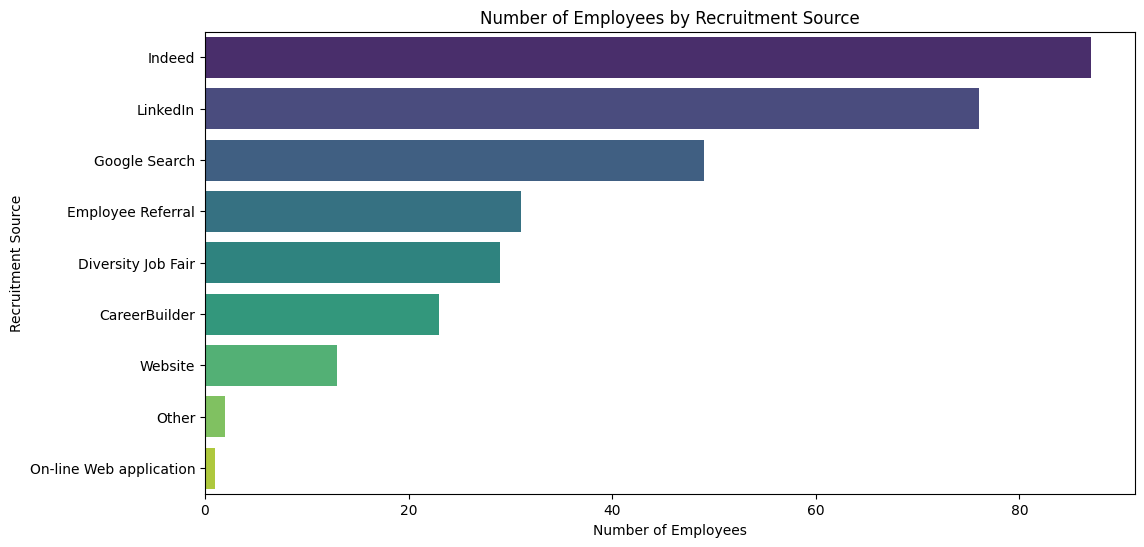

/tmp/ipython-input-18-2945738785.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Salary', y='RecruitmentSource', palette='viridis',


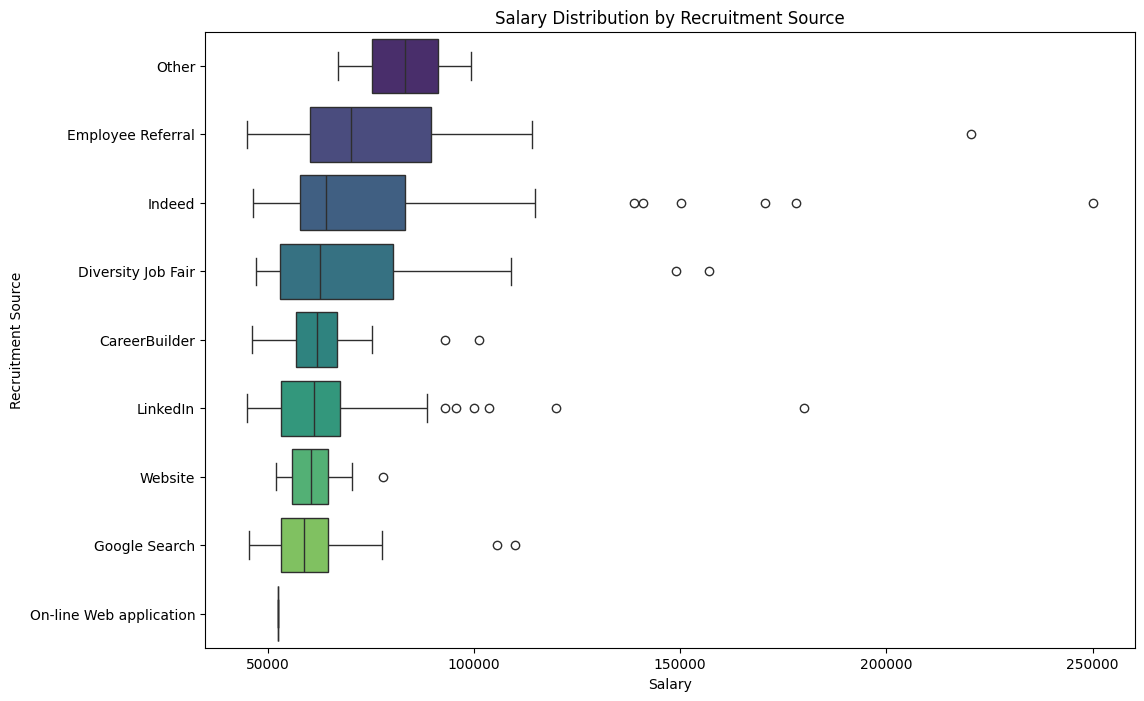

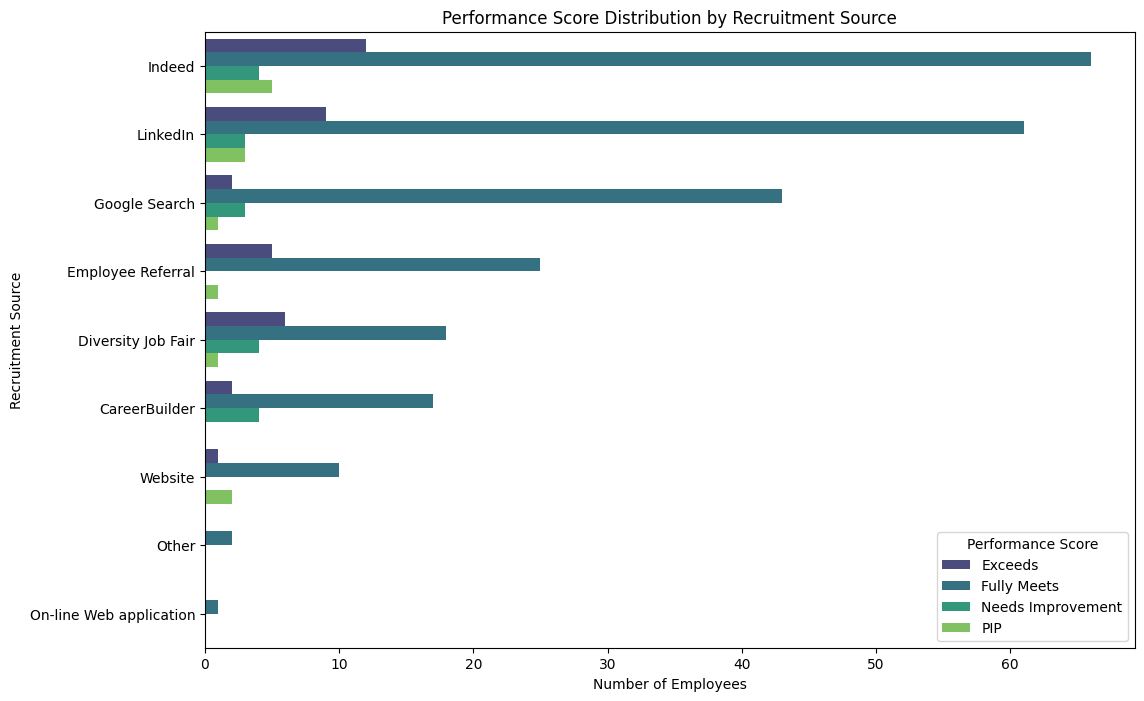

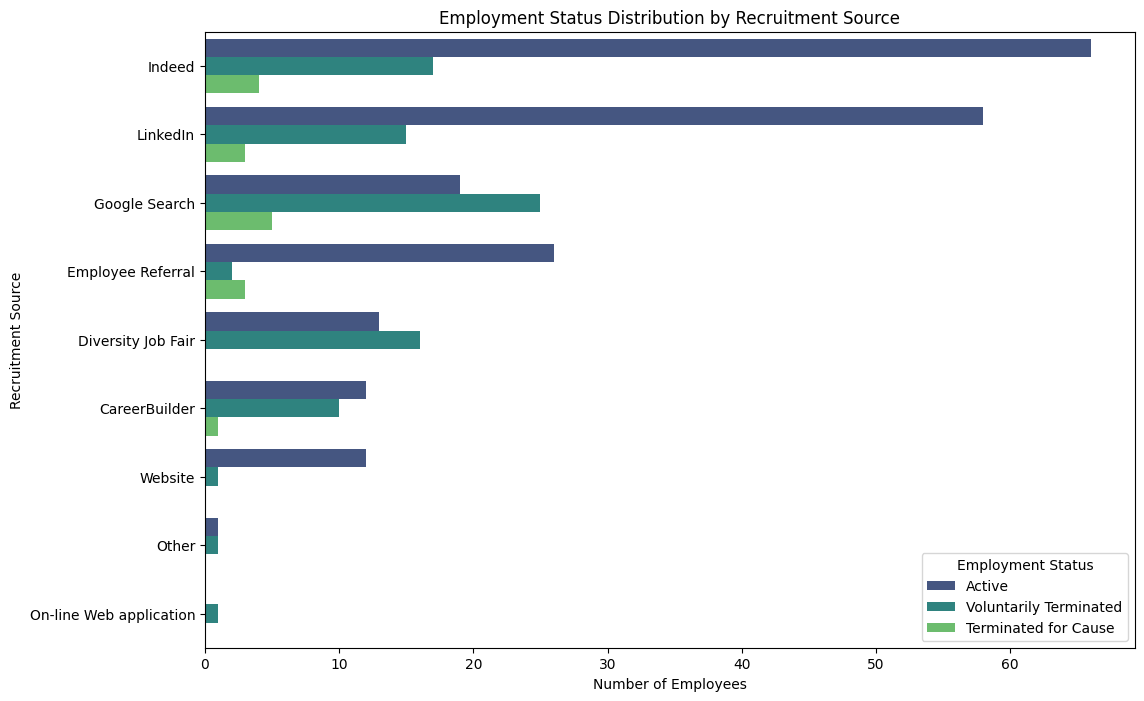

In [ ]:
# 1. Bar plot of 'RecruitmentSource'
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='RecruitmentSource', order=df['RecruitmentSource'].value_counts().index, palette='viridis')
plt.title('Number of Employees by Recruitment Source')
plt.xlabel('Number of Employees')
plt.ylabel('Recruitment Source')
plt.show()

# 2. Box plot of 'RecruitmentSource' and 'Salary'
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x='Salary', y='RecruitmentSource', palette='viridis',
            order=df.groupby('RecruitmentSource')['Salary'].median().sort_values(ascending=False).index) # Order by median salary
plt.title('Salary Distribution by Recruitment Source')
plt.xlabel('Salary')
plt.ylabel('Recruitment Source')
plt.show()

# 3. Bar plot of 'RecruitmentSource' and 'PerformanceScore'
plt.figure(figsize=(12, 8))
sns.countplot(data=df, y='RecruitmentSource', hue='PerformanceScore', palette='viridis',
              order=df['RecruitmentSource'].value_counts().index)
plt.title('Performance Score Distribution by Recruitment Source')
plt.xlabel('Number of Employees')
plt.ylabel('Recruitment Source')
plt.legend(title='Performance Score')
plt.show()

# 4. Bar plot of 'RecruitmentSource' and 'EmploymentStatus'
plt.figure(figsize=(12, 8))
sns.countplot(data=df, y='RecruitmentSource', hue='EmploymentStatus', palette='viridis',
              order=df['RecruitmentSource'].value_counts().index)
plt.title('Employment Status Distribution by Recruitment Source')
plt.xlabel('Number of Employees')
plt.ylabel('Recruitment Source')
plt.legend(title='Employment Status')
plt.show()

### 6.7 Performance & Engagement

Examine the relationship between `PerformanceScore`, `EngagementSurvey`, and `EmpSatisfaction` to understand what drives employee engagement and satisfaction.

Descriptive statistics for EngagementSurvey:


,EngagementSurvey
count,311.000000
mean,4.110000
std,0.789938
min,1.120000
25%,3.690000
50%,4.280000
75%,4.700000
max,5.000000



Descriptive statistics for EmpSatisfaction:


,EmpSatisfaction
count,311.000000
mean,3.890675
std,0.909241
min,1.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,5.000000


/tmp/ipython-input-19-2258084439.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='PerformanceScore', y='EngagementSurvey', palette='viridis',


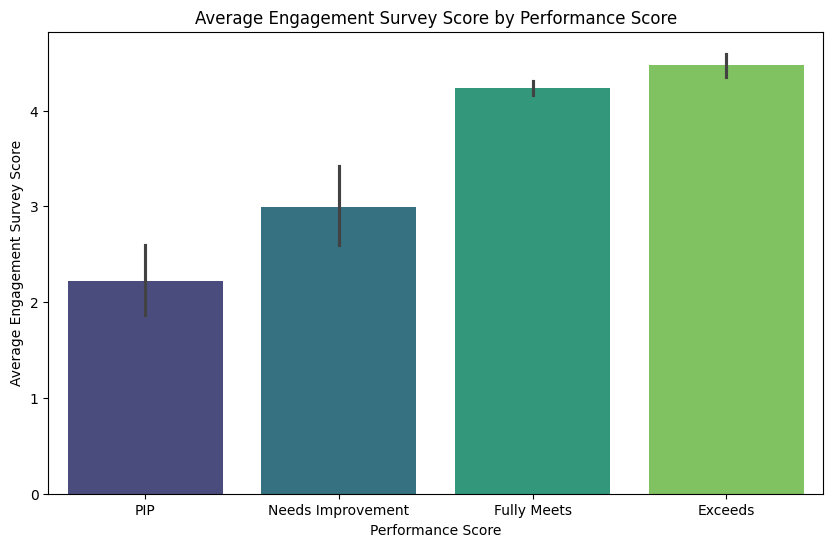

/tmp/ipython-input-19-2258084439.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='PerformanceScore', y='EmpSatisfaction', palette='viridis',


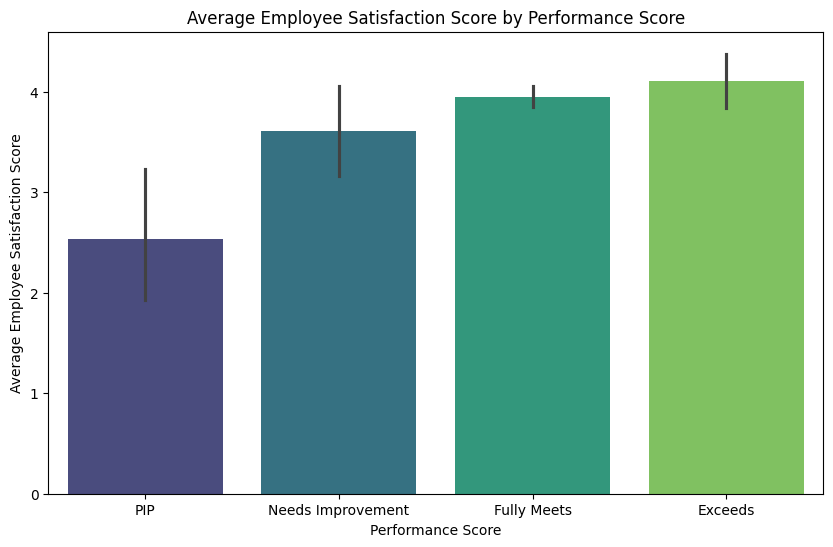

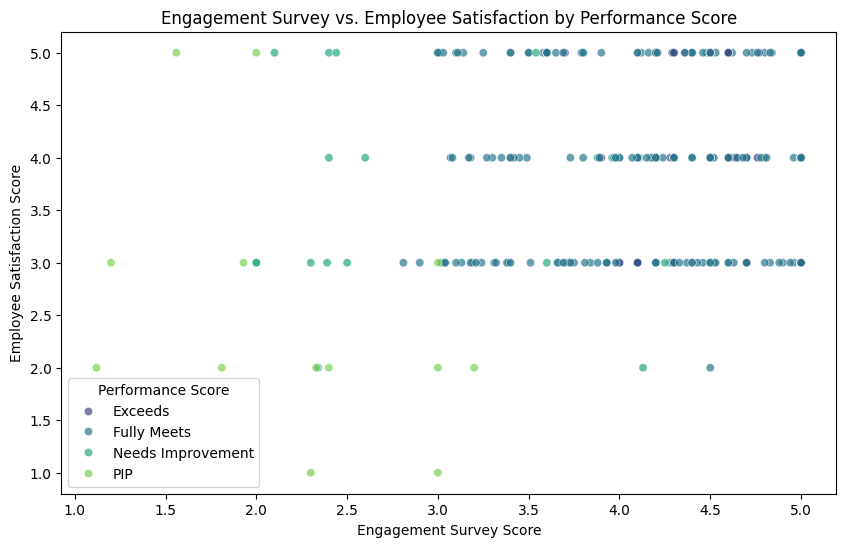

In [ ]:
# 1. Calculate and display descriptive statistics for 'EngagementSurvey' and 'EmpSatisfaction'
print("Descriptive statistics for EngagementSurvey:")
display(df['EngagementSurvey'].describe())

print("\nDescriptive statistics for EmpSatisfaction:")
display(df['EmpSatisfaction'].describe())

# 2. Create a grouped bar plot for average 'EngagementSurvey' score for each 'PerformanceScore' category
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='PerformanceScore', y='EngagementSurvey', palette='viridis',
            order=['PIP', 'Needs Improvement', 'Fully Meets', 'Exceeds']) # Ordering by perceived performance level
plt.title('Average Engagement Survey Score by Performance Score')
plt.xlabel('Performance Score')
plt.ylabel('Average Engagement Survey Score')
plt.show()

# 3. Create a grouped bar plot for average 'EmpSatisfaction' score for each 'PerformanceScore' category
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='PerformanceScore', y='EmpSatisfaction', palette='viridis',
            order=['PIP', 'Needs Improvement', 'Fully Meets', 'Exceeds']) # Ordering by perceived performance level
plt.title('Average Employee Satisfaction Score by Performance Score')
plt.xlabel('Performance Score')
plt.ylabel('Average Employee Satisfaction Score')
plt.show()

# 4. Create a scatter plot of 'EngagementSurvey' vs 'EmpSatisfaction', colored by 'PerformanceScore'
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='EngagementSurvey', y='EmpSatisfaction', hue='PerformanceScore', palette='viridis', alpha=0.7)
plt.title('Engagement Survey vs. Employee Satisfaction by Performance Score')
plt.xlabel('Engagement Survey Score')
plt.ylabel('Employee Satisfaction Score')
plt.legend(title='Performance Score')
plt.show()

### 📝 EDA Summary

| Finding | Detail |
|---|---|
| Salary distribution | Right-skewed — majority of employees fall in lower-to-mid salary ranges |
| Performance vs salary | Higher performers (`Exceeds`, `Exceptional`) tend to earn higher median salaries |
| Engagement & satisfaction | Positive correlation between `EngagementSurvey` and `EmpSatisfaction` scores |
| Top recruitment sources | Indeed and LinkedIn drive the highest employee volume |
| Dominant employment status | Majority of employees are active; among leavers, voluntary exits outnumber involuntary ones |
| Gender distribution | Female employees are more represented than male in this dataset |
| Common termination reasons | Seeking another position and dissatisfaction are the leading voluntary exit drivers |

## 7. 🏷️ Termination Reason Categorisation

The `TermReason` column contains granular exit reasons. To enable higher-level analysis, reasons are grouped into three broader categories:

- **Still Employed** — employee has not exited (`N/A-StillEmployed`)
- **Voluntary** — employee chose to leave (another position, more money, career change, relocation, retirement, etc.)
- **Involuntary** — employee was let go (performance, attendance, misconduct, no-call no-show, etc.)

In [ ]:
import pandas as pd
df_cleaned = pd.read_csv('cleaned_hr_data.csv')
display(df_cleaned.head())
display(df_cleaned.info())

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,2019-01-17,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2016-02-24,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,2012-05-15,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,2019-01-03,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2016-02-01,0,2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee_Name               311 non-null    object 
 1   EmpID                       311 non-null    int64  
 2   MarriedID                   311 non-null    int64  
 3   MaritalStatusID             311 non-null    int64  
 4   GenderID                    311 non-null    int64  
 5   EmpStatusID                 311 non-null    int64  
 6   DeptID                      311 non-null    int64  
 7   PerfScoreID                 311 non-null    int64  
 8   FromDiversityJobFairID      311 non-null    int64  
 9   Salary                      311 non-null    int64  
 10  Termd                       311 non-null    int64  
 11  PositionID                  311 non-null    int64  
 12  Position                    311 non-null    object 
 13  State                       311 non

None

### Explore the 'TermReason' column

Examine the unique values and their counts in the 'TermReason' column to understand the different reasons provided.

In [ ]:
print("Unique values and counts in 'TermReason' column:")
display(df_cleaned['TermReason'].value_counts())

Unique values and counts in 'TermReason' column:


,count
TermReason,
N/A-StillEmployed,207
Another position,20
unhappy,14
more money,11
career change,9
hours,8
attendance,7
return to school,5
relocation out of area,5


### Categorize termination reasons

Based on the unique values, create a new column with broader categories for the termination reasons.

Create a new column `TermCategory` by mapping the existing `TermReason` values to broader categories such as 'Voluntary', 'Involuntary', and 'Still Employed'. This will simplify the analysis of termination trends. After creating the new column, display the value counts to verify the categorization.

In [ ]:
def categorize_termination_reason(reason):
    if reason == 'N/A-StillEmployed':
        return 'Still Employed'
    elif reason in ['Another position', 'more money', 'career change', 'hours', 'return to school', 'relocation out of area', 'retiring', 'maternity leave - did not return', 'medical issues']:
        return 'Voluntary'
    else:
        return 'Involuntary' # Includes reasons like performance, attendance, no-call no-show, misconduct, etc.

df_cleaned['TermCategory'] = df_cleaned['TermReason'].apply(categorize_termination_reason)

print("Categorized termination reasons:")
display(df_cleaned['TermCategory'].value_counts())

Categorized termination reasons:


,count
TermCategory,
Still Employed,207
Voluntary,68
Involuntary,36


### Analyze the categorized termination reasons

Display the counts of the new termination reason categories and visualize their distribution to understand the main reasons for employee turnover.

/tmp/ipython-input-7-1585359782.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x='TermCategory', order=df_cleaned['TermCategory'].value_counts().index, palette='viridis')


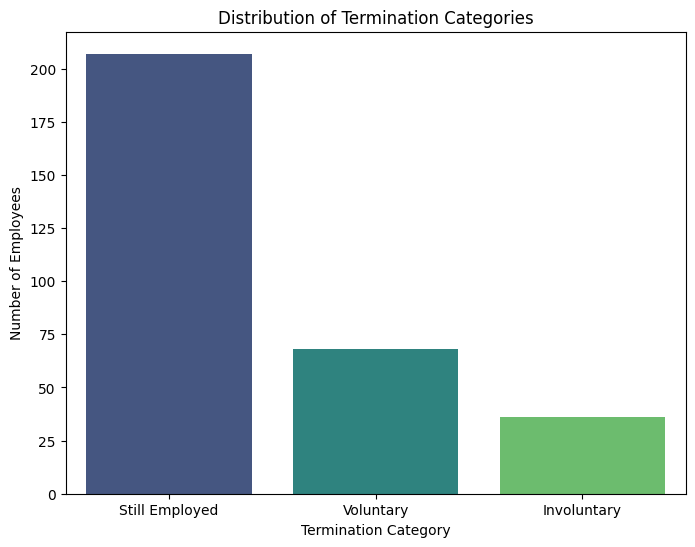

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(data=df_cleaned, x='TermCategory', order=df_cleaned['TermCategory'].value_counts().index, palette='viridis')
plt.title('Distribution of Termination Categories')
plt.xlabel('Termination Category')
plt.ylabel('Number of Employees')
plt.show()

### 📝 Termination Category Summary

Based on the categorization and analysis of the 'TermReason' column:

* The majority of employees in the dataset are still employed, as indicated by the large count in the 'Still Employed' category.
* Among the employees who have left the company, a larger portion falls under the 'Voluntary' termination category compared to 'Involuntary' terminations.
* The 'Voluntary' category includes reasons such as seeking another position, more money, career change, and returning to school, suggesting that many employees are leaving for opportunities elsewhere or for personal development.
* The 'Involuntary' category, while smaller, includes reasons related to performance, attendance, and misconduct.

This categorization provides a clearer overview of the main drivers behind employee turnover in this dataset.

## 8. 💾 Export Cleaned Dataset

Save the cleaned and enriched DataFrame as `cleaned_hr_data.csv` for use in Power BI.

In [ ]:
df.to_csv('cleaned_hr_data.csv', index=False)

---

## ✅ Notebook Complete

The raw `HRDataset_v14.csv` has been cleaned, validated, and enriched across 311 rows and 36 columns.

**Key outputs:**
- Cleaned dataset exported as `cleaned_hr_data.csv`
- `TermCategory` feature engineered from raw `TermReason` values
- EDA completed with visualisations across demographics, performance, engagement, and recruitment

The cleaned dataset was subsequently loaded into **Power BI** to build an interactive Workforce Performance & Efficiency Dashboard.

📊 **[View the full project on GitHub →](https://github.com/alisazarina/hr-analytics-dashboard/)**